In [1]:
import os
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis/')
import beamDump
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-elbex')

import numpy as _np
import matplotlib.pyplot as _plt
import pybdsim as _bd

from manchester_farm.background import beamGas
from manchester_farm.background import G4Dict

initializing ocelot...


In [2]:
def countProcesses(inputfilename):
    process_dict={}
    
    data = _bd.Data.Load(inputfilename)
    et = data.GetEventTree()
    npart = et.GetEntries()
    for i, evt in enumerate(et):
        print(f"\r Primaries : {i+1} / {npart}", end="", flush=True)
        trajdata = _bd.Data.TrajectoryData(data, i)
        chain = getPocessChain(trajdata, transport=False)
        for process in chain:
            if process not in process_dict:
                process_dict[process] = 1
            else:
                process_dict[process] += 1
    print()
    return process_dict
            
        
def getPocessChain(trajdata, transport=False, verbose=False):
    chain = []
    trajdict = trajdata.trajectories[0]
    process_types = trajdata.trajectories[0]['postPT']
    process_sub_types = trajdata.trajectories[0]['postPST']
    for Type, Subtype in zip(process_types, process_sub_types):
        if verbose:
            print(Type, Subtype)
        if Type == 1 and not transport:
            pass
        elif Type in [-1, 7, 10]:
            pass
        else:
            chain.append(getProcessName(Type, Subtype))
    return chain
        
def getProcessName(Type, Subtype):
    return G4Dict.Process_type_subtype_dict[Type]['Subtype'][Subtype]

In [3]:
def getAllCreationProcessDict(inputfilename):
    dict_creation = {}
    TrajData = beamDump.TrajData(inputfilename)
    for i in range(TrajData.npart):
        print(f"\r Primaries : {i+1} / {TrajData.npart}", end="", flush=True)
        Traj = TrajData.Trajectory(i)
        for j in range(len(Traj.track_table)):
            if Traj.track_table[j]['primaryStepIDX'] != -1:
                partIDAndProcess = Traj.getCreationProcessAndParentParticleName(j)
                if partIDAndProcess not in dict_creation:
                    dict_creation[partIDAndProcess] = 1
                else:
                    dict_creation[partIDAndProcess] += 1
    return dict_creation

In [4]:
inputfilename = "manchester_farm/background/results/outfiles/14572786_0_100000_XTD8_no_bias_high_density_1e-8.root"

In [ ]:
TrajData = beamDump.TrajData(inputfilename)

In [ ]:
s = TrajData.findUnknownPartID()

In [ ]:
s

In [5]:
d = getAllCreationProcessDict(inputfilename)

BDSIM output file - using DataLoader
 Primaries : 100000 / 100000

In [6]:
d

{('electron', ('fElectromagnetic', 'fIonisation')): 4032,
 ('electron', ('fElectromagnetic', 'fBremsstrahlung')): 3208,
 ('photon', ('fElectromagnetic', 'fPhotoElectricEffect')): 5296,
 ('photon', ('fElectromagnetic', 'fComptonScattering')): 13666,
 ('positron', ('fElectromagnetic', 'fIonisation')): 1080,
 ('photon', ('fElectromagnetic', 'fGammaConversion')): 1262,
 ('positron', ('fElectromagnetic', 'fBremsstrahlung')): 2063,
 ('positron', ('fElectromagnetic', 'fAnnihilation')): 110,
 ('photon', ('fHadronic', 'fHadronInelastic')): 11,
 ('neutron', ('fHadronic', 'fHadronInelastic')): 8,
 ('positron', ('fElectromagnetic', 'fMultipleScattering')): 2}

In [70]:
data = _bd.Data.Load("manchester_farm/background/results/outfiles/0_100000_TEST_High_density_bug.root")
t = data.GetEventTree()
e = data.GetEvent()
et = data.GetEventTree()
npart = et.GetEntries()

BDSIM output file - using DataLoader


In [78]:
partID_hist_dict = {11: 0, -11: 1, 12: 2, -12: 3,
                    22: 4,
                    2112: 5, 2212: 6,
                    13: 7, -13: 8, 14: 9, -14: 10,
                    111: 11, 211: 12, -211: 13,
                    321: 14, -321: 15}

d = {}
sampler_names = e.GetSamplerNames()
for samplername in sampler_names:
    d[samplername.data()]={"P":0, "S":0}
for evt in et:
    for samplername in sampler_names:
        sampler_data = e.GetSampler(samplername)
        if len(sampler_data.weight) != 0:
                for j, (partID, parentID) in enumerate(zip(sampler_data.partID, sampler_data.parentID)):
                    if partID == 11:
                        if parentID == 0:
                            d[samplername]["P"]+=1
                        else:
                            d[samplername]["S"]+=1

In [79]:
d

{'D1.': {'P': 100000, 'S': 1},
 'D1_1.': {'P': 99998, 'S': 36},
 'D1_2.': {'P': 99995, 'S': 621},
 'D1_3.': {'P': 99973, 'S': 1339},
 'D1_4.': {'P': 99934, 'S': 3358},
 'D1_5.': {'P': 99889, 'S': 2258},
 'D1_6.': {'P': 99852, 'S': 2253}}

REBDSIM analysis file - using RebdsimFile


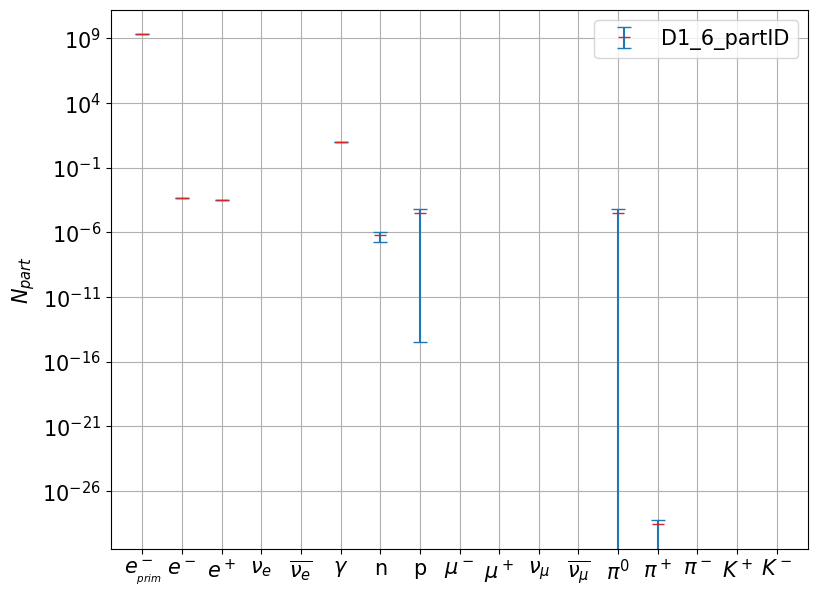

In [2]:
beamGas.plotHistogram("manchester_farm/background/results/histfiles/0_100000_TEST_High_density_bug_hist.root", "D1_6_partID", 
                      errorbars=True, partlabels=True, logY=True, xlim=None, samefig=False, figsize=[9, 7])